In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
import pandas as pd

df = pd.read_csv('/content/teen_phone_addiction_dataset.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3000, 25)


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [5]:
print("Column Names:")
for col in df.columns:
    print(col)

Column Names:
ID
Name
Age
Gender
Location
School_Grade
Daily_Usage_Hours
Sleep_Hours
Academic_Performance
Social_Interactions
Exercise_Hours
Anxiety_Level
Depression_Level
Self_Esteem
Parental_Control
Screen_Time_Before_Bed
Phone_Checks_Per_Day
Apps_Used_Daily
Time_on_Social_Media
Time_on_Gaming
Time_on_Education
Phone_Usage_Purpose
Family_Communication
Weekend_Usage_Hours
Addiction_Level


In [6]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control  

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64


In [8]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [9]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

Total Missing Values: 0


In [10]:
print(df.dtypes)

ID                          int64
Name                       object
Age                         int64
Gender                     object
Location                   object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose        object
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
dtype: object


In [11]:
features = [
    'Anxiety_Level',
    'Depression_Level',
    'Self_Esteem',
    'Sleep_Hours',
    'Daily_Usage_Hours',
    'Screen_Time_Before_Bed',
    'Social_Interactions',
    'Exercise_Hours'
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Data Shape:", X.shape)
X.head()

Selected Features:
['Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Sleep_Hours', 'Daily_Usage_Hours', 'Screen_Time_Before_Bed', 'Social_Interactions', 'Exercise_Hours']

Feature Data Shape: (3000, 8)


,Anxiety_Level,Depression_Level,Self_Esteem,Sleep_Hours,Daily_Usage_Hours,Screen_Time_Before_Bed,Social_Interactions,Exercise_Hours
0,10,3,8,6.1,4.0,1.4,5,0.1
1,3,7,3,6.5,5.5,0.9,5,0.0
2,2,3,10,5.5,5.8,0.5,8,0.8
3,9,10,3,3.9,3.1,1.4,8,1.6
4,1,5,1,6.7,2.5,1.0,4,1.1


In [12]:
X.describe()

,Anxiety_Level,Depression_Level,Self_Esteem,Sleep_Hours,Daily_Usage_Hours,Screen_Time_Before_Bed,Social_Interactions,Exercise_Hours
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,5.590000,5.460333,5.546333,6.489767,5.020667,1.006733,5.097667,1.040667
std,2.890678,2.871557,2.860754,1.490713,1.956501,0.492878,3.139333,0.734620
min,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,3.000000,5.500000,3.700000,0.700000,2.000000,0.500000
50%,6.000000,5.000000,6.000000,6.500000,5.000000,1.000000,5.000000,1.000000
75%,8.000000,8.000000,8.000000,7.500000,6.400000,1.400000,8.000000,1.500000
max,10.000000,10.000000,10.000000,10.000000,11.500000,2.600000,10.000000,4.000000


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed")
print("Scaled data shape:", X_scaled.shape)
print(X_scaled[:5])

Scaling completed
Scaled data shape: (3000, 8)
[[ 1.52584804 -0.8569369   0.85784222 -0.26150679 -0.52176662  0.79803121
  -0.03111583 -1.28069459]
 [-0.89613297  0.53626765 -0.89024001  0.00686587  0.24503605 -0.21658721
  -0.03111583 -1.41684214]
 [-1.24213026 -0.8569369   1.55707511 -0.66406578  0.39839659 -1.02828195
   0.92466042 -0.32766176]
 [ 1.17985075  1.58117107 -0.89024001 -1.73755643 -0.98184822  0.79803121
   0.92466042  0.76151861]
 [-1.58812755 -0.16033462 -1.5894729   0.1410522  -1.28856928 -0.01366353
  -0.34970791  0.08078088]]


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

print("K-Means Results")
print("----------------")

for k, inertia, score in zip(k_values, inertias, silhouette_scores):
    print(
        f"k={k} | Inertia={inertia:.2f} | "
        f"Silhouette Score={score:.4f}"
    )

K-Means Results
----------------
k=2 | Inertia=21718.04 | Silhouette Score=0.0952
k=3 | Inertia=20286.22 | Silhouette Score=0.0863
k=4 | Inertia=19131.67 | Silhouette Score=0.0890
k=5 | Inertia=18195.54 | Silhouette Score=0.0889
k=6 | Inertia=17437.75 | Silhouette Score=0.0894
k=7 | Inertia=16800.99 | Silhouette Score=0.0896
k=8 | Inertia=16279.53 | Silhouette Score=0.0886


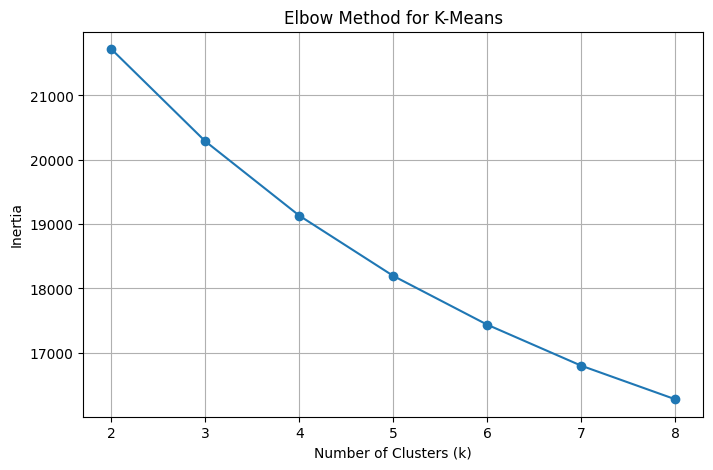

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.grid(True)
plt.show()

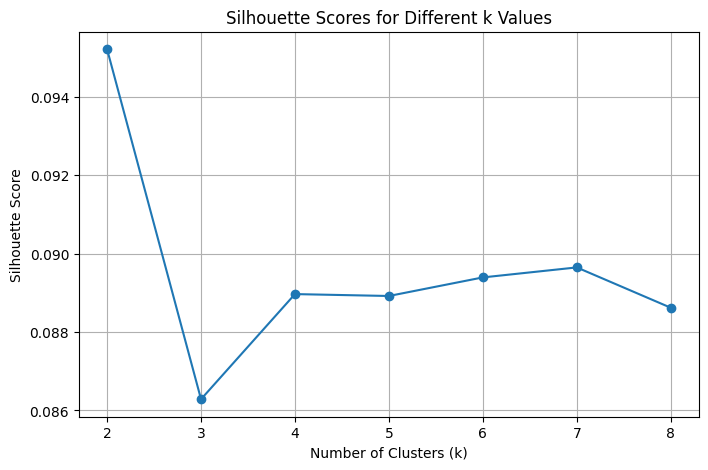

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k Values')
plt.grid(True)
plt.show()

In [17]:
emotion_features = [
    'Anxiety_Level',
    'Depression_Level',
    'Self_Esteem'
]

X_emotion = df[emotion_features].copy()

scaler_emotion = StandardScaler()
X_emotion_scaled = scaler_emotion.fit_transform(X_emotion)

print("Emotion Features:", emotion_features)
print("Shape:", X_emotion_scaled.shape)

Emotion Features: ['Anxiety_Level', 'Depression_Level', 'Self_Esteem']
Shape: (3000, 3)


In [18]:
emotion_inertias = []
emotion_silhouette_scores = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_emotion_scaled)

    emotion_inertias.append(model.inertia_)

    score = silhouette_score(
        X_emotion_scaled,
        labels
    )

    emotion_silhouette_scores.append(score)

    print(f"k={k} | Silhouette Score={score:.4f}")

k=2 | Silhouette Score=0.2458
k=3 | Silhouette Score=0.2500
k=4 | Silhouette Score=0.2708
k=5 | Silhouette Score=0.2719
k=6 | Silhouette Score=0.2852
k=7 | Silhouette Score=0.2873
k=8 | Silhouette Score=0.2915


In [19]:
refined_features = [
    'Anxiety_Level',
    'Depression_Level',
    'Self_Esteem',
    'Sleep_Hours',
    'Social_Interactions',
    'Exercise_Hours'
]

X_refined = df[refined_features].copy()

scaler_refined = StandardScaler()
X_refined_scaled = scaler_refined.fit_transform(X_refined)

print("Refined Features:", refined_features)
print("Shape:", X_refined_scaled.shape)

Refined Features: ['Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Sleep_Hours', 'Social_Interactions', 'Exercise_Hours']
Shape: (3000, 6)


In [20]:
refined_scores = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_refined_scaled)
    score = silhouette_score(X_refined_scaled, labels)

    refined_scores.append(score)

    print(f"k={k} | Silhouette Score={score:.4f}")

k=2 | Silhouette Score=0.1267
k=3 | Silhouette Score=0.1180
k=4 | Silhouette Score=0.1233
k=5 | Silhouette Score=0.1251
k=6 | Silhouette Score=0.1241
k=7 | Silhouette Score=0.1268
k=8 | Silhouette Score=0.1255


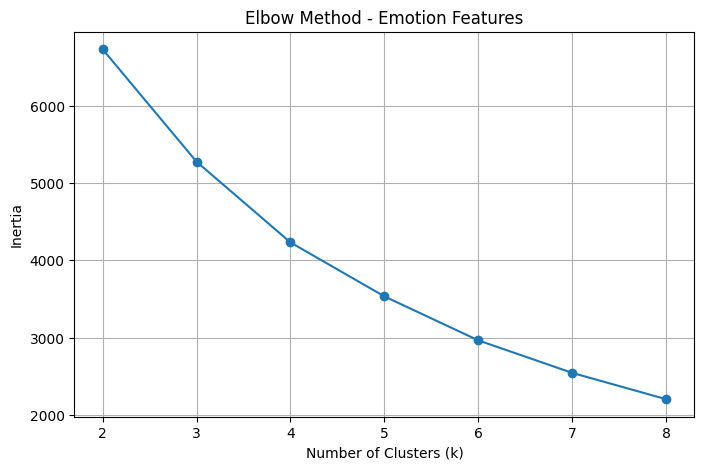

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), emotion_inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Emotion Features')
plt.grid(True)
plt.show()

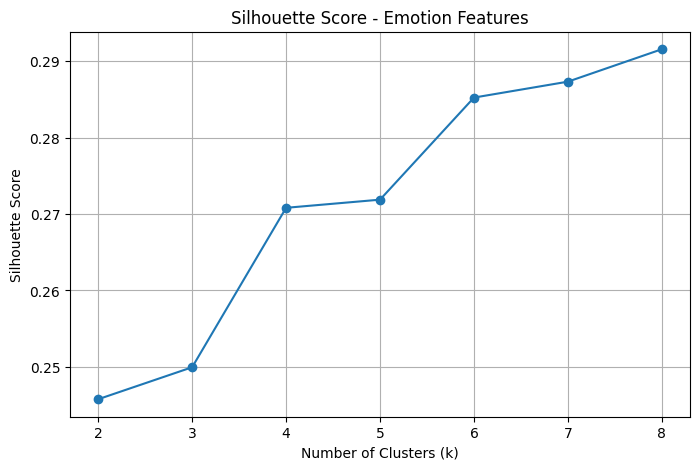

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), emotion_silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Emotion Features')
plt.grid(True)
plt.show()

In [23]:
final_k = 4

kmeans_4 = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_4.fit_predict(X_emotion_scaled)

df['Emotion_Cluster'] = cluster_labels

print("Silhouette Score:",
      silhouette_score(X_emotion_scaled, cluster_labels))

print("\nNumber of students in each cluster:")
print(df['Emotion_Cluster'].value_counts().sort_index())

Silhouette Score: 0.27080669468668894

Number of students in each cluster:
Emotion_Cluster
0    746
1    762
2    767
3    725
Name: count, dtype: int64


In [24]:
centers_scaled = kmeans_4.cluster_centers_

centers_original = scaler_emotion.inverse_transform(centers_scaled)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=emotion_features
)

cluster_centers.index = [
    'Cluster 0',
    'Cluster 1',
    'Cluster 2',
    'Cluster 3'
]

cluster_centers.round(2)

,Anxiety_Level,Depression_Level,Self_Esteem
Cluster 0,2.70,7.59,5.73
Cluster 1,5.61,3.33,2.74
Cluster 2,5.80,3.03,8.19
Cluster 3,8.31,8.08,5.50


In [25]:
cluster_names = {
    0: 'Higher Depression Pattern',
    1: 'Lower Self-Esteem Pattern',
    2: 'Positive Emotional Pattern',
    3: 'Higher Emotional Concern Pattern'
}

df['Emotion_Pattern'] = df['Emotion_Cluster'].map(cluster_names)

print(df[
    ['Anxiety_Level',
     'Depression_Level',
     'Self_Esteem',
     'Emotion_Cluster',
     'Emotion_Pattern']
].head(10))

   Anxiety_Level  Depression_Level  Self_Esteem  Emotion_Cluster  \
0             10                 3            8                2   
1              3                 7            3                0   
2              2                 3           10                2   
3              9                10            3                3   
4              1                 5            1                1   
5              7                 1            3                1   
6              6                 7            9                2   
7              5                 6            8                2   
8              1                 7            6                0   
9              9                 1            9                2   

                    Emotion_Pattern  
0        Positive Emotional Pattern  
1         Higher Depression Pattern  
2        Positive Emotional Pattern  
3  Higher Emotional Concern Pattern  
4         Lower Self-Esteem Pattern  
5         Lower Self-Es

In [26]:
print("Students per Emotional Pattern:")
print(df['Emotion_Pattern'].value_counts())

Students per Emotional Pattern:
Emotion_Pattern
Positive Emotional Pattern          767
Lower Self-Esteem Pattern           762
Higher Depression Pattern           746
Higher Emotional Concern Pattern    725
Name: count, dtype: int64


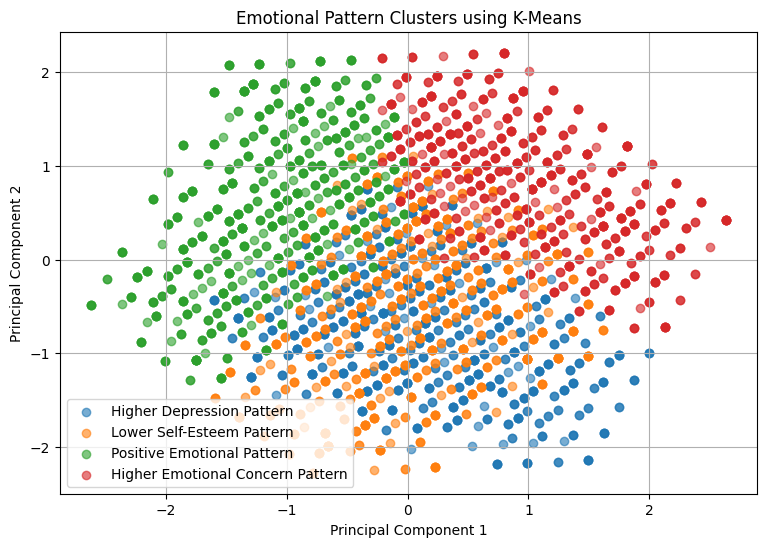

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_emotion_scaled)

plt.figure(figsize=(9, 6))

for cluster_id in range(4):
    mask = cluster_labels == cluster_id

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=cluster_names[cluster_id],
        alpha=0.6
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Emotional Pattern Clusters using K-Means')
plt.legend()
plt.grid(True)
plt.show()

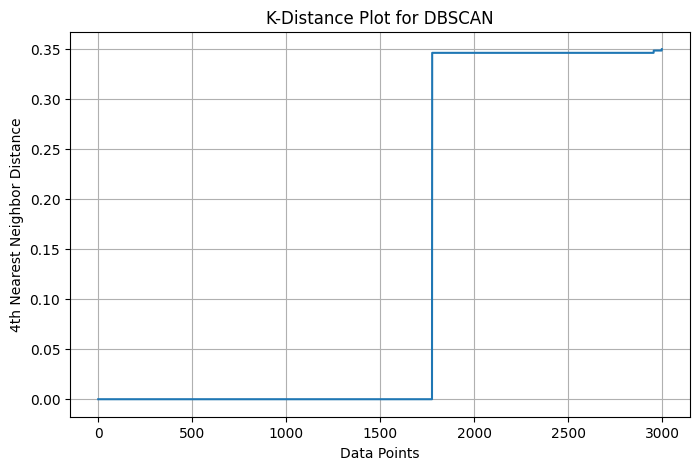

In [28]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_emotion_scaled)

distances, indices = neighbors_fit.kneighbors(X_emotion_scaled)

distances = np.sort(distances[:, 3])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("4th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")
plt.grid(True)
plt.show()

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

results = []

eps_values = [0.20, 0.30, 0.35, 0.40, 0.50]
min_samples_values = [4, 5, 8]

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_emotion_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        # Silhouette only if at least 2 valid clusters exist
        valid_mask = labels != -1
        valid_labels = labels[valid_mask]

        if len(set(valid_labels)) >= 2:
            score = silhouette_score(
                X_emotion_scaled[valid_mask],
                valid_labels
            )
        else:
            score = np.nan

        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            score
        ])

dbscan_results = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'clusters',
        'noise_points',
        'silhouette'
    ]
)

dbscan_results


,eps,min_samples,clusters,noise_points,silhouette
0,0.20,4,362,1223,1.0
1,0.20,5,195,1891,1.0
2,0.20,8,11,2908,1.0
3,0.30,4,362,1223,1.0
4,0.30,5,195,1891,1.0
5,0.30,8,11,2908,1.0
6,0.35,4,1,0,NaN
7,0.35,5,1,0,NaN
8,0.35,8,1,0,NaN
9,0.40,4,1,0,NaN


In [30]:
comparison = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN'],
    'Result': [
        '4 interpretable clusters',
        'Unstable: 11-362 clusters or 1 cluster'
    ],
    'Silhouette': [
        0.2708,
        'Not reliable for this data'
    ],
    'Interpretability': [
        'Good',
        'Poor'
    ],
    'Decision': [
        'Selected',
        'Not selected'
    ]
})

comparison

,Method,Result,Silhouette,Interpretability,Decision
0,K-Means,4 interpretable clusters,0.2708,Good,Selected
1,DBSCAN,Unstable: 11-362 clusters or 1 cluster,Not reliable for this data,Poor,Not selected


In [31]:
import joblib

joblib.dump(kmeans_4, 'emotion_kmeans_model.pkl')
joblib.dump(scaler_emotion, 'emotion_scaler.pkl')

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [32]:
def predict_emotion_pattern(anxiety, depression, self_esteem):

    input_data = pd.DataFrame(
        [[anxiety, depression, self_esteem]],
        columns=[
            'Anxiety_Level',
            'Depression_Level',
            'Self_Esteem'
        ]
    )

    input_scaled = scaler_emotion.transform(input_data)

    cluster = kmeans_4.predict(input_scaled)[0]

    pattern = cluster_names[cluster]

    return {
        'cluster': int(cluster),
        'emotion_pattern': pattern
    }

In [33]:
result = predict_emotion_pattern(
    anxiety=8,
    depression=8,
    self_esteem=5
)

print(result)

{'cluster': 3, 'emotion_pattern': 'Higher Emotional Concern Pattern'}


In [34]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_children = 20
num_days = 90
start_date = pd.Timestamp('2026-01-01')

records = []

for child in range(1, num_children + 1):

    # Different normal baseline for each child
    base_emotion = np.random.uniform(0.55, 0.85)
    base_screen = np.random.randint(120, 300)
    base_night = np.random.randint(10, 60)

    for day in range(num_days):

        date = start_date + pd.Timedelta(days=day)

        emotion_score = np.clip(
            np.random.normal(base_emotion, 0.10),
            0,
            1
        )

        screen_time_min = max(
            0,
            int(np.random.normal(base_screen, 35))
        )

        night_usage_min = max(
            0,
            int(np.random.normal(base_night, 15))
        )

        records.append({
            'child_id': f'C{child:02d}',
            'date': date,
            'emotion_score': round(emotion_score, 3),
            'screen_time_min': screen_time_min,
            'night_usage_min': night_usage_min,
            'hate_speech_flags': 0,
            'violent_video_flags': 0
        })

timeline_df = pd.DataFrame(records)

print("Synthetic Timeline Created")
print("Dataset Shape:", timeline_df.shape)

timeline_df.head(10)

Synthetic Timeline Created
Dataset Shape: (1800, 7)


,child_id,date,emotion_score,screen_time_min,night_usage_min,hate_speech_flags,violent_video_flags
0,C01,2026-01-01,0.727,265,20,0,0
1,C01,2026-01-02,0.639,267,35,0,0
2,C01,2026-01-03,0.615,230,17,0,0
3,C01,2026-01-04,0.616,220,0,0,0
4,C01,2026-01-05,0.490,192,8,0,0
5,C01,2026-01-06,0.694,180,2,0,0
6,C01,2026-01-07,0.809,204,25,0,0
7,C01,2026-01-08,0.520,192,25,0,0
8,C01,2026-01-09,0.547,225,14,0,0
9,C01,2026-01-10,0.633,190,51,0,0


In [35]:
# Start by marking every day as normal
timeline_df['is_anomaly'] = 0

# Select approximately 5% of records as anomaly days
num_anomalies = int(len(timeline_df) * 0.05)

anomaly_indices = np.random.choice(
    timeline_df.index,
    size=num_anomalies,
    replace=False
)

# Inject unusual behaviour
for idx in anomaly_indices:

    # Lower emotional score
    timeline_df.loc[idx, 'emotion_score'] = np.random.uniform(0.05, 0.30)

    # Unusually high screen time
    timeline_df.loc[idx, 'screen_time_min'] += np.random.randint(180, 360)

    # Unusually high night usage
    timeline_df.loc[idx, 'night_usage_min'] += np.random.randint(60, 180)

    # Add harmful-content related flags
    timeline_df.loc[idx, 'hate_speech_flags'] = np.random.randint(1, 5)
    timeline_df.loc[idx, 'violent_video_flags'] = np.random.randint(1, 4)

    # Ground-truth label
    timeline_df.loc[idx, 'is_anomaly'] = 1

print("Total Records:", len(timeline_df))
print("Normal Records:", (timeline_df['is_anomaly'] == 0).sum())
print("Anomaly Records:", (timeline_df['is_anomaly'] == 1).sum())
print(
    "Anomaly Percentage:",
    round(timeline_df['is_anomaly'].mean() * 100, 2),
    "%"
)

Total Records: 1800
Normal Records: 1710
Anomaly Records: 90
Anomaly Percentage: 5.0 %


In [36]:
timeline_df[timeline_df['is_anomaly'] == 1].head(10)

,child_id,date,emotion_score,screen_time_min,night_usage_min,hate_speech_flags,violent_video_flags,is_anomaly
4,C01,2026-01-05,0.249212,496,143,1,2,1
44,C01,2026-02-14,0.077042,538,130,1,2,1
49,C01,2026-02-19,0.141748,569,207,1,1,1
64,C01,2026-03-06,0.067954,431,186,1,1,1
98,C02,2026-01-09,0.273038,395,129,3,1,1
99,C02,2026-01-10,0.155860,332,148,1,3,1
101,C02,2026-01-12,0.064634,311,181,2,3,1
102,C02,2026-01-13,0.232805,317,146,2,1,1
115,C02,2026-01-26,0.180823,281,136,3,3,1
118,C02,2026-01-29,0.072813,338,149,3,3,1


In [37]:
timeline_df.to_csv(
    '/content/synthetic_labeled.csv',
    index=False
)

print("Synthetic labelled dataset saved successfully!")
print("Shape:", timeline_df.shape)

Synthetic labelled dataset saved successfully!
Shape: (1800, 8)


In [38]:
timeline_df['date'] = pd.to_datetime(timeline_df['date'])

timeline_df = timeline_df.sort_values(
    ['child_id', 'date']
).reset_index(drop=True)

timeline_df['emotion_7day_avg'] = (
    timeline_df
    .groupby('child_id')['emotion_score']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

timeline_df[
    ['child_id', 'date', 'emotion_score', 'emotion_7day_avg']
].head(10)

,child_id,date,emotion_score,emotion_7day_avg
0,C01,2026-01-01,0.727000,0.727000
1,C01,2026-01-02,0.639000,0.683000
2,C01,2026-01-03,0.615000,0.660333
3,C01,2026-01-04,0.616000,0.649250
4,C01,2026-01-05,0.249212,0.569242
5,C01,2026-01-06,0.694000,0.590035
6,C01,2026-01-07,0.809000,0.621316
7,C01,2026-01-08,0.520000,0.591745
8,C01,2026-01-09,0.547000,0.578602
9,C01,2026-01-10,0.633000,0.581173


In [39]:
# Define a negative emotion day
timeline_df['negative_day'] = (
    timeline_df['emotion_score'] < 0.40
).astype(int)

# Create one summary row per child
child_features = (
    timeline_df
    .groupby('child_id')
    .agg(
        avg_emotion=('emotion_score', 'mean'),
        emotion_std=('emotion_score', 'std'),
        negative_day_share=('negative_day', 'mean'),
        avg_7day_emotion=('emotion_7day_avg', 'mean')
    )
    .reset_index()
)

# Convert share to percentage
child_features['negative_day_share'] *= 100

print("Child Feature Dataset Shape:", child_features.shape)

child_features.round(3)

Child Feature Dataset Shape: (20, 5)


,child_id,avg_emotion,emotion_std,negative_day_share,avg_7day_emotion
0,C01,0.641,0.156,4.444,0.641
1,C02,0.666,0.181,7.778,0.665
2,C03,0.600,0.121,6.667,0.598
3,C04,0.730,0.112,2.222,0.730
4,C05,0.655,0.144,5.556,0.661
5,C06,0.663,0.168,6.667,0.662
6,C07,0.671,0.137,5.556,0.674
7,C08,0.515,0.145,16.667,0.514
8,C09,0.623,0.106,3.333,0.622
9,C10,0.609,0.141,7.778,0.605


In [40]:
from sklearn.preprocessing import StandardScaler

temporal_features = [
    'avg_emotion',
    'emotion_std',
    'negative_day_share',
    'avg_7day_emotion'
]

X_temporal = child_features[temporal_features]

temporal_scaler = StandardScaler()
X_temporal_scaled = temporal_scaler.fit_transform(X_temporal)

print("Temporal features scaled successfully")
print("Shape:", X_temporal_scaled.shape)

Temporal features scaled successfully
Shape: (20, 4)


In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

temporal_inertias = []
temporal_silhouette_scores = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_temporal_scaled)

    inertia = model.inertia_
    score = silhouette_score(X_temporal_scaled, labels)

    temporal_inertias.append(inertia)
    temporal_silhouette_scores.append(score)

    print(
        f"k={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={score:.4f}"
    )

k=2 | Inertia=41.94 | Silhouette=0.4159
k=3 | Inertia=27.94 | Silhouette=0.4220
k=4 | Inertia=18.54 | Silhouette=0.3562
k=5 | Inertia=13.26 | Silhouette=0.3384
k=6 | Inertia=10.72 | Silhouette=0.3189
k=7 | Inertia=6.99 | Silhouette=0.3349
k=8 | Inertia=5.20 | Silhouette=0.3325


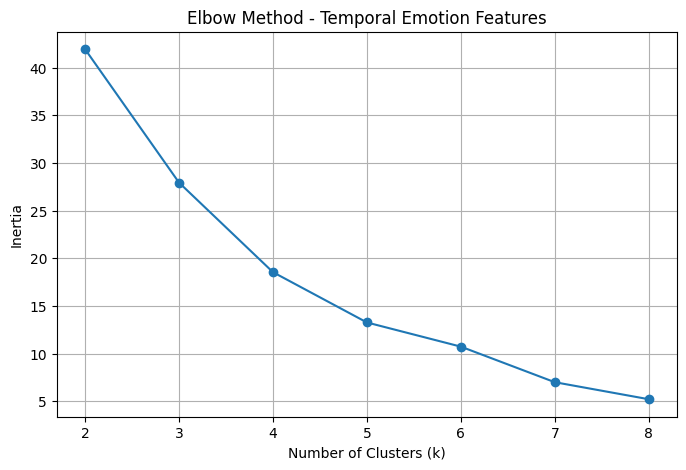

In [42]:
import matplotlib.pyplot as plt

k_values = list(range(2, 9))

plt.figure(figsize=(8, 5))
plt.plot(k_values, temporal_inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Temporal Emotion Features')
plt.grid(True)
plt.show()

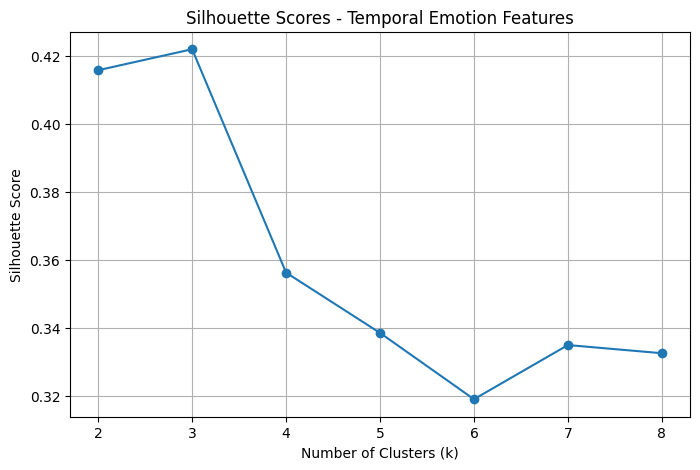

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, temporal_silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - Temporal Emotion Features')
plt.grid(True)
plt.show()

In [44]:
final_temporal_k = 3

temporal_kmeans = KMeans(
    n_clusters=final_temporal_k,
    random_state=42,
    n_init=10
)

temporal_labels = temporal_kmeans.fit_predict(X_temporal_scaled)

child_features['Emotion_Cluster'] = temporal_labels

final_score = silhouette_score(
    X_temporal_scaled,
    temporal_labels
)

print("Final k:", final_temporal_k)
print("Final Silhouette Score:", round(final_score, 4))

print("\nChildren per Cluster:")
print(
    child_features['Emotion_Cluster']
    .value_counts()
    .sort_index()
)

Final k: 3
Final Silhouette Score: 0.422

Children per Cluster:
Emotion_Cluster
0     1
1    12
2     7
Name: count, dtype: int64


In [45]:
temporal_centers_scaled = temporal_kmeans.cluster_centers_

temporal_centers_original = temporal_scaler.inverse_transform(
    temporal_centers_scaled
)

temporal_cluster_centers = pd.DataFrame(
    temporal_centers_original,
    columns=temporal_features
)

temporal_cluster_centers.index = [
    'Cluster 0',
    'Cluster 1',
    'Cluster 2'
]

temporal_cluster_centers.round(3)

,avg_emotion,emotion_std,negative_day_share,avg_7day_emotion
Cluster 0,0.718,0.240,12.222,0.717
Cluster 1,0.690,0.146,4.537,0.691
Cluster 2,0.558,0.132,10.000,0.557


In [46]:
temporal_cluster_names = {
    0: 'Variable Emotional Pattern',
    1: 'Stable Emotional Pattern',
    2: 'Lower Emotional Pattern'
}

child_features['Emotion_Pattern'] = (
    child_features['Emotion_Cluster']
    .map(temporal_cluster_names)
)

child_features[
    [
        'child_id',
        'avg_emotion',
        'emotion_std',
        'negative_day_share',
        'Emotion_Cluster',
        'Emotion_Pattern'
    ]
].round(3)

,child_id,avg_emotion,emotion_std,negative_day_share,Emotion_Cluster,Emotion_Pattern
0,C01,0.641,0.156,4.444,1,Stable Emotional Pattern
1,C02,0.666,0.181,7.778,1,Stable Emotional Pattern
2,C03,0.600,0.121,6.667,2,Lower Emotional Pattern
3,C04,0.730,0.112,2.222,1,Stable Emotional Pattern
4,C05,0.655,0.144,5.556,1,Stable Emotional Pattern
5,C06,0.663,0.168,6.667,1,Stable Emotional Pattern
6,C07,0.671,0.137,5.556,1,Stable Emotional Pattern
7,C08,0.515,0.145,16.667,2,Lower Emotional Pattern
8,C09,0.623,0.106,3.333,1,Stable Emotional Pattern
9,C10,0.609,0.141,7.778,2,Lower Emotional Pattern


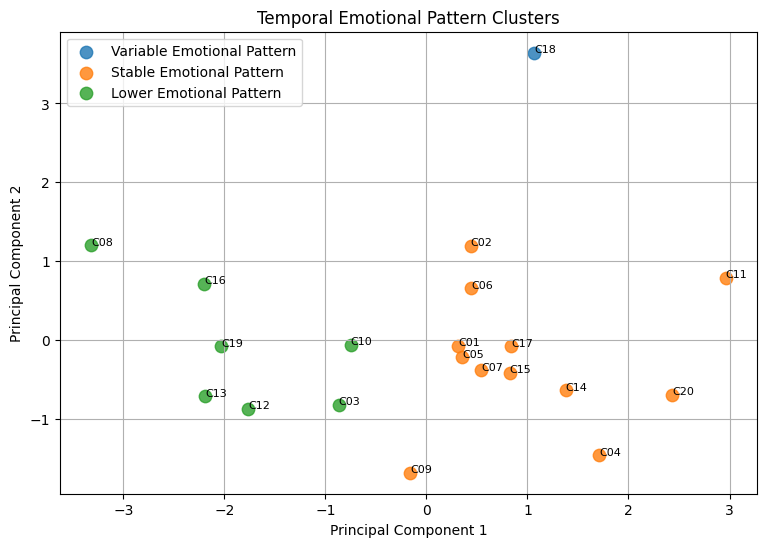

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_temporal = PCA(n_components=2)
X_temporal_pca = pca_temporal.fit_transform(X_temporal_scaled)

plt.figure(figsize=(9, 6))

for cluster_id in range(3):
    mask = temporal_labels == cluster_id

    plt.scatter(
        X_temporal_pca[mask, 0],
        X_temporal_pca[mask, 1],
        label=temporal_cluster_names[cluster_id],
        s=80,
        alpha=0.8
    )

# Add child IDs
for i, child_id in enumerate(child_features['child_id']):
    plt.annotate(
        child_id,
        (X_temporal_pca[i, 0], X_temporal_pca[i, 1]),
        fontsize=8
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Temporal Emotional Pattern Clusters')
plt.legend()
plt.grid(True)
plt.show()